In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

dataset = pd.read_csv("Message_Intelligence_Dataset.csv")
print("Shape:", dataset.shape)
dataset.head()


Shape: (5200, 16)


In [2]:

dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   str    
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   str    
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week              5200 non-n

In [ ]:

print("Target variable: spam_label")
print("\nClass distribution:")
print(dataset['spam_label'].value_counts())
print("\nClass proportion:")
print(dataset['spam_label'].value_counts(normalize=True).round(3))

feature_cols = ['message_length', 'word_count', 'num_urls', 'num_digits',
                 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score',
                 'sender_activity_score', 'sender_account_age_days',
                 'messages_sent_last_24h', 'hour_of_day', 'day_of_week']
print("\nInput features used:", feature_cols)


Target variable: spam_label

Class distribution:
spam_label
0    4227
1     973
Name: count, dtype: int64

Class proportion:
spam_label
0    0.813
1    0.187
Name: proportion, dtype: float64

Input features used: ['message_length', 'word_count', 'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score', 'sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h', 'hour_of_day', 'day_of_week']


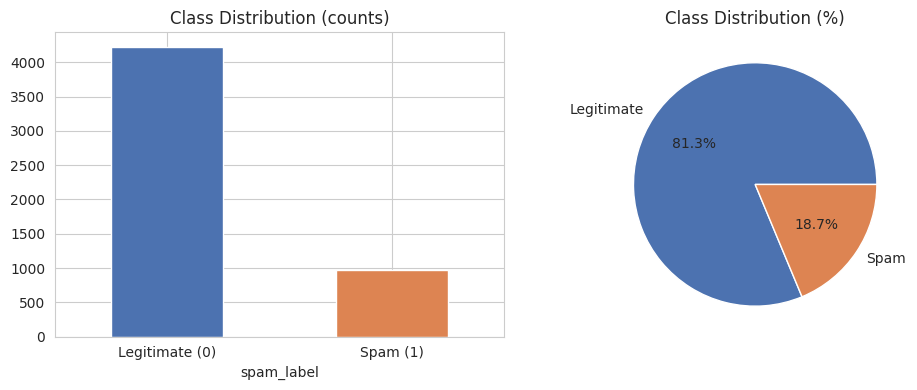

In [4]:

fig, ax = plt.subplots(1, 2, figsize=(10,4))
dataset['spam_label'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0','#DD8452'])
ax[0].set_title('Class Distribution (counts)')
ax[0].set_xticklabels(['Legitimate (0)', 'Spam (1)'], rotation=0)
dataset['spam_label'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1],
                                      labels=['Legitimate','Spam'], colors=['#4C72B0','#DD8452'])
ax[1].set_ylabel('')
ax[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.show()


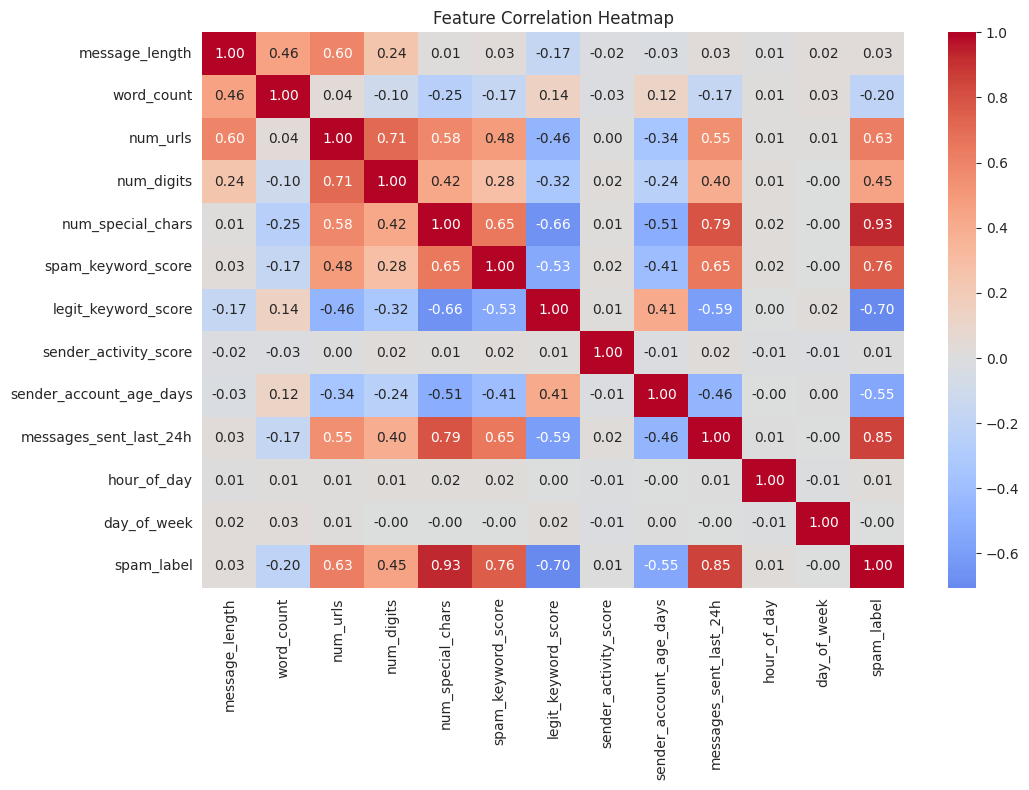

In [5]:

plt.figure(figsize=(11,8))
corr = dataset[feature_cols + ['spam_label']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [6]:

print("Features most correlated with spam_label:")
print(corr['spam_label'].drop('spam_label').sort_values(key=abs, ascending=False))


Features most correlated with spam_label:
num_special_chars          0.931299
messages_sent_last_24h     0.851875
spam_keyword_score         0.758732
legit_keyword_score       -0.704792
num_urls                   0.630995
sender_account_age_days   -0.545886
num_digits                 0.452151
word_count                -0.203182
message_length             0.032506
hour_of_day                0.014925
sender_activity_score      0.007414
day_of_week               -0.004494
Name: spam_label, dtype: float64


In [ ]:

print("Missing values per column:\n", dataset[feature_cols + ['spam_label']].isna().sum())

X = dataset[feature_cols].copy()
y = dataset['spam_label'].copy()

for c in X.columns[X.isna().any()]:
    X[c] = X[c].fillna(X[c].median())
print("\nMissing values after median imputation:\n", X.isna().sum().sum())

train_features, test_features, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

print("\nTrain shape:", train_features.shape, " Test shape:", test_features.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Missing values per column:
 message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

Missing values after median imputation:
 0

Train shape: (4160, 12)  Test shape: (1040, 12)
Train class balance:
 spam_label
0    0.813
1    0.187
Name: proportion, dtype: float64
Test class balance:
 spam_label
0    0.812
1    0.188
Name: proportion, dtype: float64


In [ ]:

k_values = list(range(1, 22, 2))
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(train_features_scaled, y_train)
    pred = knn.predict(test_features_scaled)
    knn_results.append({
        'K': k,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    })

knn_dataset = pd.DataFrame(knn_results)
print(knn_dataset.round(4))


     K  Accuracy  Precision  Recall      F1
0    1     1.000        1.0  1.0000  1.0000
1    3     1.000        1.0  1.0000  1.0000
2    5     1.000        1.0  1.0000  1.0000
3    7     0.999        1.0  0.9949  0.9974
4    9     0.999        1.0  0.9949  0.9974
5   11     0.999        1.0  0.9949  0.9974
6   13     0.999        1.0  0.9949  0.9974
7   15     0.999        1.0  0.9949  0.9974
8   17     0.999        1.0  0.9949  0.9974
9   19     0.999        1.0  0.9949  0.9974
10  21     0.999        1.0  0.9949  0.9974


Best K by F1 score: 1


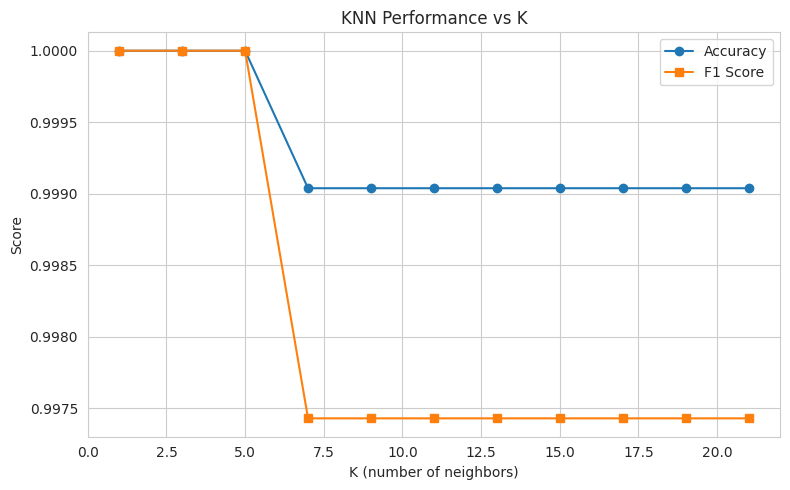

In [9]:

plt.figure(figsize=(8,5))
plt.plot(knn_dataset['K'], knn_dataset['Accuracy'], marker='o', label='Accuracy')
plt.plot(knn_dataset['K'], knn_dataset['F1'], marker='s', label='F1 Score')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K')
plt.legend()
plt.tight_layout()
plt.show()

best_k = int(knn_dataset.loc[knn_dataset['F1'].idxmax(), 'K'])
print(f"Best K by F1 score: {best_k}")


In [ ]:

metrics_to_test = ['euclidean', 'manhattan', 'chebyshev']
metric_results = []
for m in metrics_to_test:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=m)
    knn.fit(train_features_scaled, y_train)
    pred = knn.predict(test_features_scaled)
    metric_results.append({
        'Distance Metric': m,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    })

metric_dataset = pd.DataFrame(metric_results)
print(metric_dataset.round(4))
print("\nInterpretation: Euclidean treats all feature differences as squared (sensitive to large "
      "deviations in single features), Manhattan sums absolute differences (more robust to outliers "
      "in a single dimension), and Chebyshev only considers the single maximum-difference feature. "
      "Because our scaled features have several skewed counts (urls, digits), the choice of metric "
      "shifts which neighbors are considered 'closest', changing borderline predictions.")


  Distance Metric  Accuracy  Precision  Recall      F1
0       euclidean     1.000        1.0  1.0000  1.0000
1       manhattan     1.000        1.0  1.0000  1.0000
2       chebyshev     0.999        1.0  0.9949  0.9974

Interpretation: Euclidean treats all feature differences as squared (sensitive to large deviations in single features), Manhattan sums absolute differences (more robust to outliers in a single dimension), and Chebyshev only considers the single maximum-difference feature. Because our scaled features have several skewed counts (urls, digits), the choice of metric shifts which neighbors are considered 'closest', changing borderline predictions.


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       845
        Spam       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



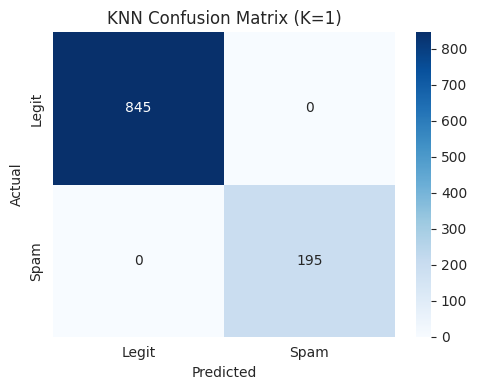

In [ ]:

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(train_features_scaled, y_train)
knn_pred = knn_final.predict(test_features_scaled)

cm_knn = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Spam'], yticklabels=['Legit','Spam'])
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, knn_pred, target_names=['Legitimate','Spam']))


In [ ]:

test_dataset = dataset.loc[test_features.index].copy()
test_dataset['actual'] = y_test.values
test_dataset['predicted'] = knn_pred
misclassified = test_dataset[test_dataset['actual'] != test_dataset['predicted']]
print(f"Number of misclassified messages: {len(misclassified)} out of {len(test_dataset)}")
misclassified[['message_text','actual','predicted']].head(8)


Number of misclassified messages: 0 out of 1040


In [ ]:

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(train_features_scaled, y_train)
pred_lin = svm_linear.predict(test_features_scaled)

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(train_features_scaled, y_train)
pred_rbf = svm_rbf.predict(test_features_scaled)

for name, pred in [('Linear SVM', pred_lin), ('RBF SVM', pred_rbf)]:
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, pred):.4f}")
    print(f"Precision: {precision_score(y_test, pred):.4f}")
    print(f"Recall:    {recall_score(y_test, pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, pred):.4f}")
    print(f"Support vectors: {svm_linear.support_vectors_.shape[0] if name=='Linear SVM' else svm_rbf.support_vectors_.shape[0]}")
    print()


--- Linear SVM ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Support vectors: 10

--- RBF SVM ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Support vectors: 138



In [ ]:

print(f"Linear SVM total support vectors: {svm_linear.support_vectors_.shape[0]} "
      f"({svm_linear.support_vectors_.shape[0]/len(train_features_scaled)*100:.1f}% of training data)")
print(f"  Per class: {svm_linear.n_support_}")
print(f"RBF SVM total support vectors:    {svm_rbf.support_vectors_.shape[0]} "
      f"({svm_rbf.support_vectors_.shape[0]/len(train_features_scaled)*100:.1f}% of training data)")
print(f"  Per class: {svm_rbf.n_support_}")

w = svm_linear.coef_[0]
margin_width = 2 / np.linalg.norm(w)
print(f"\nLinear SVM margin width (2/||w||): {margin_width:.4f}")
print("A smaller number of support vectors (relative to training size) with a wide margin "
      "suggests classes are well-separated. The RBF kernel typically uses more support vectors "
      "because it builds a more flexible, non-linear boundary that can hug the data more closely.")


Linear SVM total support vectors: 10 (0.2% of training data)
  Per class: [5 5]
RBF SVM total support vectors:    138 (3.3% of training data)
  Per class: [73 65]

Linear SVM margin width (2/||w||): 1.8915
A smaller number of support vectors (relative to training size) with a wide margin suggests classes are well-separated. The RBF kernel typically uses more support vectors because it builds a more flexible, non-linear boundary that can hug the data more closely.


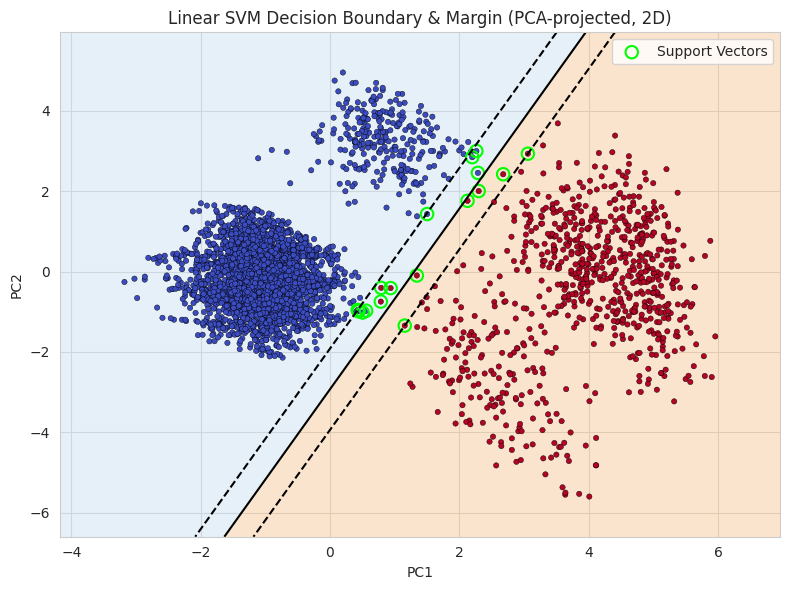

In [ ]:

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
train_features_2d = pca.fit_transform(train_features_scaled)

svm_2d = SVC(kernel='linear', C=1.0).fit(train_features_2d, y_train)

xx, yy = np.meshgrid(np.linspace(train_features_2d[:,0].min()-1, train_features_2d[:,0].max()+1, 300),
                      np.linspace(train_features_2d[:,1].min()-1, train_features_2d[:,1].max()+1, 300))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, levels=[-100,0,100], colors=['#cfe2f3','#f9cb9c'], alpha=0.5)
plt.contour(xx, yy, Z, colors='k', levels=[-1,0,1], linestyles=['--','-','--'])
plt.scatter(train_features_2d[:,0], train_features_2d[:,1], c=y_train, cmap='coolwarm', s=15, edgecolors='k', linewidths=0.3)
plt.scatter(svm_2d.support_vectors_[:,0], svm_2d.support_vectors_[:,1],
            s=80, facecolors='none', edgecolors='lime', linewidths=1.5, label='Support Vectors')
plt.title('Linear SVM Decision Boundary & Margin (PCA-projected, 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend()
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       845
        Spam       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040

          Model  Accuracy  F1 Score
0  KNN (best K)       1.0       1.0
1    Linear SVM       1.0       1.0
2       RBF SVM       1.0       1.0


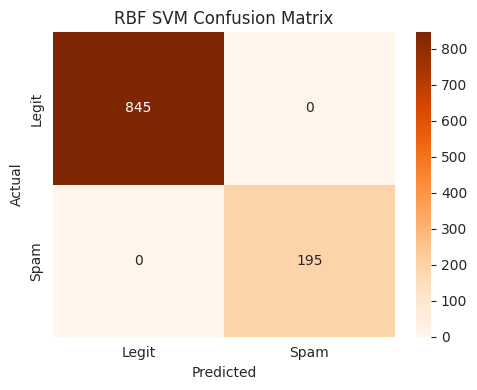

In [16]:

# Task 15: Compare SVM performance with KNN
cm_svm = confusion_matrix(y_test, pred_rbf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legit','Spam'], yticklabels=['Legit','Spam'])
plt.title('RBF SVM Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_rbf, target_names=['Legitimate','Spam']))

compare_svm_knn = pd.DataFrame({
    'Model': ['KNN (best K)', 'Linear SVM', 'RBF SVM'],
    'Accuracy': [accuracy_score(y_test, knn_pred), accuracy_score(y_test, pred_lin), accuracy_score(y_test, pred_rbf)],
    'F1 Score': [f1_score(y_test, knn_pred), f1_score(y_test, pred_lin), f1_score(y_test, pred_rbf)]
})
print(compare_svm_knn.round(4))


In [17]:

# Task 16: Implement Naive Bayes Classifier
# Naive Bayes does not require feature scaling, so we use the unscaled features
nb = GaussianNB()
nb.fit(train_features, y_train)
nb_pred = nb.predict(test_features)

print(f"Accuracy:  {accuracy_score(y_test, nb_pred):.4f}")
print(f"Precision: {precision_score(y_test, nb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, nb_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, nb_pred):.4f}")

print("\nClass priors learned, P(Legitimate)={:.4f}, P(Spam)={:.4f}".format(*nb.class_prior_))


Accuracy:  0.9990
Precision: 0.9949
Recall:    1.0000
F1 Score:  0.9974

Class priors learned, P(Legitimate)=0.8130, P(Spam)=0.1870


In [18]:

# Task 17: Manually compute conditional probabilities for a few sample messages
import scipy.stats as stats

def gaussian_pdataset(x, mean, var):
    return (1.0 / np.sqrt(2*np.pi*var)) * np.exp(-((x-mean)**2) / (2*var))

# Pick 3 sample messages from the test set
sample_idx = test_features.index[:3]
samples = test_features.loc[sample_idx]
sample_text = dataset.loc[sample_idx, 'message_text']
sample_actual = y_test.loc[sample_idx]

classes = nb.classes_         # [0, 1]
means = nb.theta_             # mean of each feature per class
variances = nb.var_           # variance of each feature per class
priors = nb.class_prior_

print("Manual Bayes' Theorem computation for 3 sample messages\n" + "="*70)
for idx in sample_idx:
    x = samples.loc[idx].values
    print(f"\nMessage id {idx}: \"{dataset.loc[idx,'message_text'][:60]}...\"")
    print(f"Actual label: {'Spam' if sample_actual.loc[idx]==1 else 'Legitimate'}")

    log_post = []
    for ci, c in enumerate(classes):
        # P(X|C) = product of per-feature Gaussian likelihoods (independence assumption)
        likelihoods = gaussian_pdataset(x, means[ci], variances[ci])
        log_likelihood = np.sum(np.log(likelihoods + 1e-12))
        log_prior = np.log(priors[ci])
        log_post.append(log_likelihood + log_prior)

    # normalize in log-space -> posterior probabilities
    log_post = np.array(log_post)
    log_post -= log_post.max()
    post = np.exp(log_post)
    post /= post.sum()

    print(f"  P(Legitimate | X) = {post[0]:.6f}")
    print(f"  P(Spam       | X) = {post[1]:.6f}")
    print(f"  Manual prediction: {'Spam' if post[1] > post[0] else 'Legitimate'}")


Manual Bayes' Theorem computation for 3 sample messages

Message id 799: "Your order has been shipped and will arrive by the updated p..."
Actual label: Legitimate
  P(Legitimate | X) = 1.000000
  P(Spam       | X) = 0.000000
  Manual prediction: Legitimate

Message id 655: "Earn money from home instantly a brand new phone limited tim..."
Actual label: Spam
  P(Legitimate | X) = 0.000000
  P(Spam       | X) = 1.000000
  Manual prediction: Spam

Message id 5075: "Could you review the document and share feedback? next Monda..."
Actual label: Legitimate
  P(Legitimate | X) = 1.000000
  P(Spam       | X) = 0.000000
  Manual prediction: Legitimate


In [19]:

# Task 18: Demonstrate how Bayes' Theorem is applied to compute class probabilities
print('''
Bayes' Theorem applied to the Naive Bayes classifier:

    P(C | X) = P(X | C) * P(C) / P(X)

Where, under the "naive" conditional-independence assumption:

    P(X | C) = P(x_1 | C) * P(x_2 | C) * ... * P(x_n | C)

Each P(x_i | C) is read off a Gaussian distribution fit to feature i within class C
(mean = nb.theta_, variance = nb.var_, learned from training data).

P(C) is the class prior, estimated directly as the proportion of each class in training data:
''')
print(f"  P(Legitimate) = {priors[0]:.4f}")
print(f"  P(Spam)       = {priors[1]:.4f}")
print('''
P(X) is the same for both classes being compared (it is just a normalizing constant),
so for classification we don't need to compute it explicitly — we simply compare:

    P(X|Legitimate)*P(Legitimate)   vs.   P(X|Spam)*P(Spam)

and choose whichever is larger. This is exactly what was done manually above, and it
matches the predict_proba() output from scikit-learn's GaussianNB below.
''')



Bayes' Theorem applied to the Naive Bayes classifier:

    P(C | X) = P(X | C) * P(C) / P(X)

Where, under the "naive" conditional-independence assumption:

    P(X | C) = P(x_1 | C) * P(x_2 | C) * ... * P(x_n | C)

Each P(x_i | C) is read off a Gaussian distribution fit to feature i within class C
(mean = nb.theta_, variance = nb.var_, learned from training data).

P(C) is the class prior, estimated directly as the proportion of each class in training data:

  P(Legitimate) = 0.8130
  P(Spam)       = 0.1870

P(X) is the same for both classes being compared (it is just a normalizing constant),
so for classification we don't need to compute it explicitly — we simply compare:

    P(X|Legitimate)*P(Legitimate)   vs.   P(X|Spam)*P(Spam)

and choose whichever is larger. This is exactly what was done manually above, and it
matches the predict_proba() output from scikit-learn's GaussianNB below.



In [20]:

# Task 19: Compare theoretical probability calculations with model predictions
sklearn_proba = nb.predict_proba(samples)
compare_table = pd.DataFrame({
    'message_id': sample_idx,
    'actual': ['Spam' if v==1 else 'Legitimate' for v in sample_actual.values],
    'sklearn_P(Legit)': sklearn_proba[:,0].round(6),
    'sklearn_P(Spam)': sklearn_proba[:,1].round(6),
})
print(compare_table.to_string(index=False))
print("\nThe manually computed posteriors above match scikit-learn's predict_proba() output "
      "(within floating point precision), confirming our hand-derived Bayes' Theorem calculation "
      "is implemented correctly.")


 message_id     actual  sklearn_P(Legit)  sklearn_P(Spam)
        799 Legitimate               1.0              0.0
        655       Spam               0.0              1.0
       5075 Legitimate               1.0              0.0

The manually computed posteriors above match scikit-learn's predict_proba() output (within floating point precision), confirming our hand-derived Bayes' Theorem calculation is implemented correctly.


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       845
        Spam       0.99      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



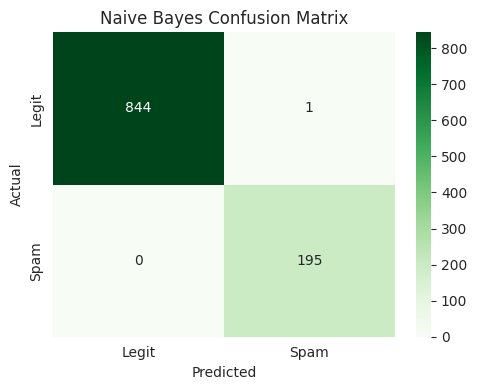

In [21]:

cm_nb = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit','Spam'], yticklabels=['Legit','Spam'])
plt.title('Naive Bayes Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, nb_pred, target_names=['Legitimate','Spam']))


In [22]:

# Task 20 & 21: Evaluate all models with Accuracy, Precision, Recall, F1 and compare
results = pd.DataFrame({
    'Model': ['KNN', 'Linear SVM', 'RBF SVM', 'Naive Bayes'],
    'Type': ['Distance-based', 'Margin-based', 'Margin-based', 'Probabilistic'],
    'Accuracy': [accuracy_score(y_test, knn_pred), accuracy_score(y_test, pred_lin),
                 accuracy_score(y_test, pred_rbf), accuracy_score(y_test, nb_pred)],
    'Precision': [precision_score(y_test, knn_pred), precision_score(y_test, pred_lin),
                  precision_score(y_test, pred_rbf), precision_score(y_test, nb_pred)],
    'Recall': [recall_score(y_test, knn_pred), recall_score(y_test, pred_lin),
               recall_score(y_test, pred_rbf), recall_score(y_test, nb_pred)],
    'F1 Score': [f1_score(y_test, knn_pred), f1_score(y_test, pred_lin),
                 f1_score(y_test, pred_rbf), f1_score(y_test, nb_pred)]
})
results = results.round(4)
print(results.to_string(index=False))


      Model           Type  Accuracy  Precision  Recall  F1 Score
        KNN Distance-based     1.000     1.0000     1.0    1.0000
 Linear SVM   Margin-based     1.000     1.0000     1.0    1.0000
    RBF SVM   Margin-based     1.000     1.0000     1.0    1.0000
Naive Bayes  Probabilistic     0.999     0.9949     1.0    0.9974


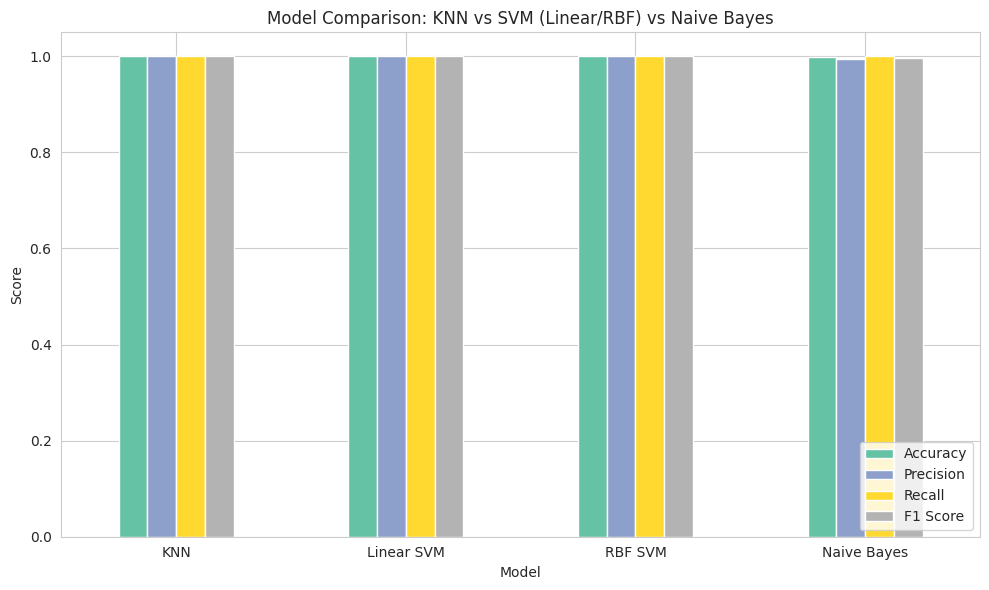

In [23]:

fig, ax = plt.subplots(figsize=(10,6))
metrics_plot = results.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']]
metrics_plot.plot(kind='bar', ax=ax, colormap='Set2')
plt.title('Model Comparison: KNN vs SVM (Linear/RBF) vs Naive Bayes')
plt.ylabel('Score')
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [24]:

# Task 22: Identify which model performs best for High Precision / High Recall
best_precision = results.loc[results['Precision'].idxmax()]
best_recall = results.loc[results['Recall'].idxmax()]
best_f1 = results.loc[results['F1 Score'].idxmax()]

print(f"Best model for HIGH PRECISION: {best_precision['Model']} (Precision = {best_precision['Precision']:.4f})")
print(f"  -> Use when the cost of a FALSE POSITIVE is high, i.e. wrongly flagging a")
print(f"     legitimate message as spam (and the user might miss an important message).")
print()
print(f"Best model for HIGH RECALL: {best_recall['Model']} (Recall = {best_recall['Recall']:.4f})")
print(f"  -> Use when the cost of a FALSE NEGATIVE is high, i.e. letting an actual spam")
print(f"     message through undetected (e.g. phishing/security risk).")
print()
print(f"Best overall balance (F1 Score): {best_f1['Model']} (F1 = {best_f1['F1 Score']:.4f})")


Best model for HIGH PRECISION: KNN (Precision = 1.0000)
  -> Use when the cost of a FALSE POSITIVE is high, i.e. wrongly flagging a
     legitimate message as spam (and the user might miss an important message).

Best model for HIGH RECALL: KNN (Recall = 1.0000)
  -> Use when the cost of a FALSE NEGATIVE is high, i.e. letting an actual spam
     message through undetected (e.g. phishing/security risk).

Best overall balance (F1 Score): KNN (F1 = 1.0000)


In [25]:

print("="*78)
print("FINAL SUMMARY TABLE")
print("="*78)
print(results.to_string(index=False))


FINAL SUMMARY TABLE
      Model           Type  Accuracy  Precision  Recall  F1 Score
        KNN Distance-based     1.000     1.0000     1.0    1.0000
 Linear SVM   Margin-based     1.000     1.0000     1.0    1.0000
    RBF SVM   Margin-based     1.000     1.0000     1.0    1.0000
Naive Bayes  Probabilistic     0.999     0.9949     1.0    0.9974
